# Optimizacion Objetivo A - Compras Presenciales POS

Este notebook desarrolla el punto 6 del Objetivo A: optimizar el modelo para reducir falsos positivos en compras presenciales con tarjeta. Parte del dataset de variables generado para Bolivia y del baseline LightGBM, pero entrena nuevas variantes con metricas `feval` personalizadas, ajustes de pesos y comparacion cuantitativa.

Objetivo operativo: minimizar `FP / (TP + FP)` en transacciones POS presenciales, buscando mantener al menos `90%` de deteccion de fraude cuando se ajusta el umbral.

## 1) Configuracion

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 180)

RANDOM_STATE = 42
TARGET_RECALL = 0.90
target_col = 'is_fraud'


## 2) Carga de datos y definicion del segmento POS

Se usa el archivo producido por el notebook de ingenieria de variables. El segmento objetivo es `is_card_present_purchase == True`, equivalente a compras presenciales POS atendidas.

In [2]:
candidate_paths = [Path('../data/bolivia_features_obj_a.csv.gz'), Path('data/bolivia_features_obj_a.csv.gz')]
features_path = next((p for p in candidate_paths if p.exists()), None)
if features_path is None:
    raise FileNotFoundError('No se encontro data/bolivia_features_obj_a.csv.gz. Ejecuta primero el notebook de ingenieria de variables.')

df = pd.read_csv(features_path)
df['tx_datetime'] = pd.to_datetime(df['tx_datetime'], errors='coerce')
if df[target_col].dtype != bool:
    df[target_col] = df[target_col].map(lambda x: str(x).lower() == 'true')

pos_eval_mask = df['is_card_present_purchase'].astype(bool)

display(pd.DataFrame({
    'dataset': ['Bolivia features', 'POS presencial'],
    'rows': [len(df), int(pos_eval_mask.sum())],
    'frauds': [int(df[target_col].sum()), int(df.loc[pos_eval_mask, target_col].sum())],
    'fraud_rate_pct': [df[target_col].mean() * 100, df.loc[pos_eval_mask, target_col].mean() * 100],
}).round(3))

print(f'Ruta usada: {features_path.resolve()}')
display(df.head())


,dataset,rows,frauds,fraud_rate_pct
0,Bolivia features,100003,4919,4.919
1,POS presencial,39128,877,2.241


Ruta usada: C:\Users\josue\uvg\Semestre 9\Security DS\federated-banking-fraud\data\bolivia_features_obj_a.csv.gz


,transaction_id,client_id,tx_datetime,channel,DE60_pos_terminal_type,is_fraud,amount_usd,amount_local,amount_tx_currency,client_baseline_amount,DE4_amount_transaction,DE6_amount_cardholder_billing,DE9_conversion_rate_billing,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE49_currency_code_transaction,DE123_pos_data_code,is_pos_attended,is_card_present_purchase,is_ecom,is_atm,is_moto,is_domestic,is_foreign_currency,is_international_pos,requires_pin,has_emv,amount_usd_log1p,amount_vs_client_baseline,amount_over_baseline_flag,client_txn_count_prev,client_amount_mean_prev,client_amount_median_prev,client_amount_std_prev,amount_zscore_customer,amount_vs_client_mean_prev,amount_vs_client_median_prev,amount_vs_mcc_mean_prev,amount_vs_merchant_mean_prev,time_since_last_txn_min,txn_count_prev_1h,txn_count_prev_6h,txn_count_prev_24h,txn_count_prev_7d,amount_sum_prev_1h,amount_sum_prev_6h,amount_sum_prev_24h,amount_sum_prev_7d,client_merchant_count_prev,is_first_client_merchant,client_mcc_count_prev,is_first_client_mcc,client_currency_count_prev,is_first_client_currency,client_acquirer_country_count_prev,is_first_client_acquirer_country,client_entry_mode_count_prev,is_first_client_entry_mode,channel_fraud_rate_prev_smooth,DE60_pos_terminal_type_fraud_rate_prev_smooth,DE18_merchant_category_code_fraud_rate_prev_smooth,DE22_pos_entry_mode_fraud_rate_prev_smooth,DE25_pos_condition_code_fraud_rate_prev_smooth,currency_tx_alpha_fraud_rate_prev_smooth,hour,day_num,is_weekend,is_night,hour_sin,hour_cos,day_sin,day_cos,client_segment,card_brand,currency_tx_alpha,client_home_city,DE52_pin_data_present,DE55_emv_data_present
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP-CL-00001325,2025-01-01 00:01:51,POS,POS-ATTENDED,False,500.12,3450.82,393.79,2012.51,39379,345082,87630970.0,5651,826,72,1.0,0,826,07200N,True,True,False,False,False,False,True,True,False,False,6.216846,0.248506,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.049189,0.049189,0.049189,0.049189,0.049189,0.049189,20,1,False,False,-0.866025,0.5,0.781831,0.62349,PLATINUM,MASTERCARD,GBP,TARIJA,N,N
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP-CL-00000079,2025-01-01 00:03:55,ECOM,ECOM-VIRTUAL,False,1898.93,13102.64,13102.64,1096.46,1310264,1310264,10000000.0,4511,68,81,2.0,59,68,08159N,False,False,True,False,False,True,False,False,False,False,7.549572,1.731873,True,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.049189,0.049189,0.049189,0.049189,0.049189,0.049189,20,1,False,False,-0.866025,0.5,0.781831,0.62349,PRIVATE,VISA,BOB,LAPAZ,N,N
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP-CL-00002344,2025-01-01 00:04:10,ECOM,ECOM-VIRTUAL,False,349.85,2413.94,2413.94,1528.37,241394,241394,10000000.0,5732,68,81,2.0,59,68,08159N,False,False,True,False,False,True,False,False,False,False,5.860359,0.228904,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.048224,0.048224,0.049189,0.048224,0.048224,0.048224,20,1,False,False,-0.866025,0.5,0.781831,0.62349,INFINITE,NaN,BOB,SANTACRUZ,N,N
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP-CL-00002587,2025-01-01 00:04:53,ATM,ATM-UNATTENDED,False,345.58,2384.49,314.16,2483.34,31416,238449,75900496.0,6011,250,51,2.0,0,978,05100Y,False,False,False,True,False,False,True,False,True,True,5.848114,0.139159,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.049189,0.049189,0.049189,0.049189,0.048224,0.049189,20,1,False,False,-0.866025,0.5,0.781831,0.62349,PLATINUM,VISA,EUR,SUCRE,Y,Y
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP-CL-00000087,2025-01-01 00:07:56,POS,POS-ATTENDED,False,118.90,820.38,820.38,1334.55,82038,82038,10000000.0,5812,68,21,3.0,0,68,02100Y,True,True,False,False,False,True,False,False,True,False,4.786658,0.089094,False,0,NaN,Na

## 3) Separacion temporal para optimizacion

Para la optimizacion se evita usar el periodo de prueba para tomar decisiones internas. Se entrena con enero-febrero, se usa marzo para early stopping/seleccion de iteracion y se evalua abril-junio como ultimo trimestre.

In [3]:
fit_mask = df['tx_datetime'] < pd.Timestamp('2025-03-01')
valid_mask = (df['tx_datetime'] >= pd.Timestamp('2025-03-01')) & (df['tx_datetime'] < pd.Timestamp('2025-04-01'))
test_mask = df['tx_datetime'] >= pd.Timestamp('2025-04-01')

reference_cols = ['transaction_id', 'client_id', 'tx_datetime', 'channel', 'DE60_pos_terminal_type']
feature_cols = [c for c in df.columns if c not in reference_cols + [target_col]]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
y = df[target_col].astype(int)

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

split_summary = []
for name, mask in [('fit_ene_feb', fit_mask), ('valid_mar', valid_mask), ('test_abr_jun', test_mask), ('test_abr_jun_pos', test_mask & pos_eval_mask)]:
    split_summary.append({
        'subset': name,
        'rows': int(mask.sum()),
        'frauds': int(y.loc[mask].sum()),
        'fraud_rate_pct': y.loc[mask].mean() * 100,
    })

display(pd.DataFrame(split_summary).round(3))
print(f'Features: {len(feature_cols)} | numericas/bool: {len(numeric_cols)} | categoricas: {len(categorical_cols)}')
print(categorical_cols)


,subset,rows,frauds,fraud_rate_pct
0,fit_ene_feb,32899,1628,4.948
1,valid_mar,17130,898,5.242
2,test_abr_jun,49974,2393,4.788
3,test_abr_jun_pos,19513,427,2.188


Features: 75 | numericas/bool: 68 | categoricas: 7
['DE123_pos_data_code', 'client_segment', 'card_brand', 'currency_tx_alpha', 'client_home_city', 'DE52_pin_data_present', 'DE55_emv_data_present']


## 4) Preprocesamiento comun

Todas las estrategias usan el mismo preprocesamiento para que la comparacion sea justa. Las diferencias entre estrategias vienen de la metrica custom y de los pesos/parametros del modelo.

In [4]:
try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', one_hot)]), categorical_cols),
    ],
    remainder='drop',
)

preprocess_fit = clone(preprocess)
X_fit = preprocess_fit.fit_transform(X.loc[fit_mask], y.loc[fit_mask])
X_valid = preprocess_fit.transform(X.loc[valid_mask])
X_valid_pos = preprocess_fit.transform(X.loc[valid_mask & pos_eval_mask])
X_test = preprocess_fit.transform(X.loc[test_mask])
X_test_pos = preprocess_fit.transform(X.loc[test_mask & pos_eval_mask])

y_fit = y.loc[fit_mask].to_numpy()
y_valid = y.loc[valid_mask].to_numpy()
y_valid_pos = y.loc[valid_mask & pos_eval_mask].to_numpy()
y_test = y.loc[test_mask].to_numpy()
y_test_pos = y.loc[test_mask & pos_eval_mask].to_numpy()

train_data = lgb.Dataset(X_fit, label=y_fit, free_raw_data=False)
valid_pos_data = lgb.Dataset(X_valid_pos, label=y_valid_pos, reference=train_data, free_raw_data=False)
valid_all_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data, free_raw_data=False)


## 5) Funciones `feval` personalizadas

Se disenaron tres metricas orientadas al objetivo diferenciado del grupo:

1. `pos_fp_ratio_at_recall90`: minimiza la ratio `FP/(TP+FP)` en el umbral que alcanza 90% de recall.
2. `pos_fp_per_tp_at_recall90`: minimiza falsos positivos por fraude detectado, tambien al 90% de recall.
3. `pos_cost_with_recall_floor`: penaliza falsos positivos y agrega castigo si el recall baja de 90%.

Como el primer `valid_set` durante entrenamiento contiene solo POS de marzo, estas metricas se optimizan sobre el segmento objetivo.

In [5]:
def safe_counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return int(tn), int(fp), int(fn), int(tp)

def threshold_for_target_recall(y_true, proba, target_recall=TARGET_RECALL):
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    positives = int(y_true.sum())
    if positives == 0:
        return 1.0
    order = np.argsort(-proba)
    sorted_y = y_true[order]
    sorted_scores = proba[order]
    cumulative_tp = np.cumsum(sorted_y)
    required_tp = int(np.ceil(target_recall * positives))
    cutoff_idx = int(np.argmax(cumulative_tp >= required_tp))
    return float(sorted_scores[cutoff_idx])

def fp_ratio(y_true, y_pred):
    _, fp, _, tp = safe_counts(y_true, y_pred)
    alerts = tp + fp
    return fp / alerts if alerts else 1.0

def fp_per_tp(y_true, y_pred):
    _, fp, _, tp = safe_counts(y_true, y_pred)
    return fp / tp if tp else np.inf

def feval_pos_fp_ratio_at_recall90(preds, dataset):
    y_true = dataset.get_label().astype(int)
    threshold = threshold_for_target_recall(y_true, preds, TARGET_RECALL)
    y_pred = (preds >= threshold).astype(int)
    return 'pos_fp_ratio_at_recall90', fp_ratio(y_true, y_pred), False

def feval_pos_fp_per_tp_at_recall90(preds, dataset):
    y_true = dataset.get_label().astype(int)
    threshold = threshold_for_target_recall(y_true, preds, TARGET_RECALL)
    y_pred = (preds >= threshold).astype(int)
    return 'pos_fp_per_tp_at_recall90', fp_per_tp(y_true, y_pred), False

def feval_pos_cost_with_recall_floor(preds, dataset):
    y_true = dataset.get_label().astype(int)
    y_pred = (preds >= 0.50).astype(int)
    recall = recall_score(y_true, y_pred, zero_division=0)
    cost = fp_ratio(y_true, y_pred) + 4 * max(0, TARGET_RECALL - recall) ** 2
    return 'pos_cost_with_recall_floor', cost, False

print('Metricas custom listas.')


Metricas custom listas.


## 6) Experimentos de optimizacion

Se ajustan pesos y parametros para explorar distintos balances entre deteccion y falsas alertas. El baseline AUC queda como referencia, y las variantes custom usan pesos positivos mas moderados o regularizacion mayor para controlar falsos positivos.

In [6]:
base_pos_weight = (len(y_fit) - y_fit.sum()) / y_fit.sum()

experiments = [
    {
        'name': 'baseline_auc_balanced',
        'description': 'Referencia: AUC con peso balanceado',
        'feval': None,
        'metric': 'auc',
        'scale_pos_weight': base_pos_weight,
        'num_leaves': 31,
        'min_data_in_leaf': 80,
        'lambda_l2': 1.0,
    },
    {
        'name': 'feval_fp_ratio_recall90_w075',
        'description': 'Minimiza ratio FP con 90% recall y peso positivo moderado',
        'feval': feval_pos_fp_ratio_at_recall90,
        'metric': 'None',
        'scale_pos_weight': base_pos_weight * 0.75,
        'num_leaves': 31,
        'min_data_in_leaf': 120,
        'lambda_l2': 3.0,
    },
    {
        'name': 'feval_fp_per_tp_recall90_w060',
        'description': 'Minimiza FP por fraude detectado con peso positivo conservador',
        'feval': feval_pos_fp_per_tp_at_recall90,
        'metric': 'None',
        'scale_pos_weight': base_pos_weight * 0.60,
        'num_leaves': 25,
        'min_data_in_leaf': 150,
        'lambda_l2': 5.0,
    },
    {
        'name': 'feval_cost_floor_w090',
        'description': 'Costo combinado: FP y penalizacion por recall bajo 90%',
        'feval': feval_pos_cost_with_recall_floor,
        'metric': 'None',
        'scale_pos_weight': base_pos_weight * 0.90,
        'num_leaves': 31,
        'min_data_in_leaf': 100,
        'lambda_l2': 2.0,
    },
]

boosters = {}
for exp in experiments:
    params = {
        'objective': 'binary',
        'metric': exp['metric'],
        'learning_rate': 0.04,
        'num_leaves': exp['num_leaves'],
        'min_data_in_leaf': exp['min_data_in_leaf'],
        'lambda_l2': exp['lambda_l2'],
        'feature_fraction': 0.9,
        'bagging_fraction': 0.9,
        'bagging_freq': 1,
        'scale_pos_weight': exp['scale_pos_weight'],
        'seed': RANDOM_STATE,
        'verbosity': -1,
        'first_metric_only': True,
    }
    booster = lgb.train(
        params=params,
        train_set=train_data,
        num_boost_round=1200,
        valid_sets=[valid_pos_data, valid_all_data],
        valid_names=['valid_mar_pos', 'valid_mar_all'],
        feval=exp['feval'],
        callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False), lgb.log_evaluation(period=0)],
    )
    boosters[exp['name']] = booster
    print(f"{exp['name']} | best_iteration={booster.best_iteration} | scale_pos_weight={exp['scale_pos_weight']:.3f}")


baseline_auc_balanced | best_iteration=48 | scale_pos_weight=19.208


feval_fp_ratio_recall90_w075 | best_iteration=12 | scale_pos_weight=14.406


feval_fp_per_tp_recall90_w060 | best_iteration=9 | scale_pos_weight=11.525


feval_cost_floor_w090 | best_iteration=20 | scale_pos_weight=17.287


## 7) Evaluacion comun de estrategias

La seleccion final se realiza en el ultimo trimestre, priorizando POS presencial. Para cada modelo se reporta el resultado con threshold `0.50` y el resultado ajustando el threshold para alcanzar 90% de recall.

In [7]:
def metrics_at_threshold(y_true, proba, threshold):
    y_pred = (np.asarray(proba) >= threshold).astype(int)
    tn, fp, fn, tp = safe_counts(y_true, y_pred)
    alerts = tp + fp
    return {
        'threshold': threshold,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'alerts': alerts,
        'recall_pct': recall_score(y_true, y_pred, zero_division=0) * 100,
        'precision_pct': precision_score(y_true, y_pred, zero_division=0) * 100,
        'fp_ratio_pct': (fp / alerts * 100) if alerts else 100,
        'fp_per_tp': (fp / tp) if tp else np.inf,
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

def evaluate_model(name, booster, X_eval, y_eval, segment):
    proba = booster.predict(X_eval, num_iteration=booster.best_iteration)
    m050 = metrics_at_threshold(y_eval, proba, 0.50)
    recall_threshold = threshold_for_target_recall(y_eval, proba, TARGET_RECALL)
    mt = metrics_at_threshold(y_eval, proba, recall_threshold)
    return {
        'strategy': name,
        'segment': segment,
        'best_iteration': booster.best_iteration,
        'auc_roc': roc_auc_score(y_eval, proba) if len(np.unique(y_eval)) == 2 else np.nan,
        'tp_050': m050['tp'],
        'fp_050': m050['fp'],
        'recall_050_pct': m050['recall_pct'],
        'precision_050_pct': m050['precision_pct'],
        'fp_ratio_050_pct': m050['fp_ratio_pct'],
        'f1_050': m050['f1'],
        'threshold_recall90': mt['threshold'],
        'tp_recall90': mt['tp'],
        'fp_recall90': mt['fp'],
        'fn_recall90': mt['fn'],
        'recall90_pct': mt['recall_pct'],
        'precision_recall90_pct': mt['precision_pct'],
        'fp_ratio_recall90_pct': mt['fp_ratio_pct'],
        'fp_per_tp_recall90': mt['fp_per_tp'],
    }

rows = []
for exp in experiments:
    booster = boosters[exp['name']]
    rows.append(evaluate_model(exp['name'], booster, X_test, y_test, 'ultimo_trimestre_todas'))
    rows.append(evaluate_model(exp['name'], booster, X_test_pos, y_test_pos, 'ultimo_trimestre_pos'))

comparison_df = pd.DataFrame(rows)
display(comparison_df[[
    'strategy', 'segment', 'auc_roc', 'f1_050', 'tp_050', 'fp_050', 'recall_050_pct', 'fp_ratio_050_pct',
    'threshold_recall90', 'tp_recall90', 'fp_recall90', 'recall90_pct', 'precision_recall90_pct',
    'fp_ratio_recall90_pct', 'fp_per_tp_recall90'
]].round(4))


,strategy,segment,auc_roc,f1_050,tp_050,fp_050,recall_050_pct,fp_ratio_050_pct,threshold_recall90,tp_recall90,fp_recall90,recall90_pct,precision_recall90_pct,fp_ratio_recall90_pct,fp_per_tp_recall90
0,baseline_auc_balanced,ultimo_trimestre_todas,0.8991,0.6348,1855,1596,77.5178,46.2475,0.1086,2154,23318,90.0125,8.4563,91.5437,10.8254
1,baseline_auc_balanced,ultimo_trimestre_pos,0.7756,0.5051,221,227,51.7564,50.6696,0.0718,385,14630,90.1639,2.5641,97.4359,38.0000
2,feval_fp_ratio_recall90_w075,ultimo_trimestre_todas,0.8971,0.0000,0,0,0.0000,100.0000,0.0759,2154,23421,90.0125,8.4223,91.5777,10.8733
3,feval_fp_ratio_recall90_w075,ultimo_trimestre_pos,0.7733,0.0000,0,0,0.0000,100.0000,0.0573,385,15332,90.1639,2.4496,97.5504,39.8234
4,feval_fp_per_tp_recall90_w060,ultimo_trimestre_todas,0.8966,0.0000,0,0,0.0000,100.0000,0.0659,2154,22459,90.0125,8.7515,91.2485,10.4266
5,feval_fp_per_tp_recall90_w060,ultimo_trimestre_pos,0.7730,0.0000,0,0,0.0000,100.0000,0.0538,389,15253,91.1007,2.4869,97.5131,39.2108
6,feval_cost_floor_w090,ultimo_trimestre_todas,0.8964,0.7671,1784,474,74.5508,20.9920,0.0982,2154,23036,90.0125,8.5510,91.4490,10.6945
7,feval_cost_floor_w090,ultimo_trimestre_pos,0.7686,0.5161,192,125,44.9649,39.4322,0.0739,385,15737,90.1639,2.3880,97.6120,40.8753


## 8) Comparacion visual

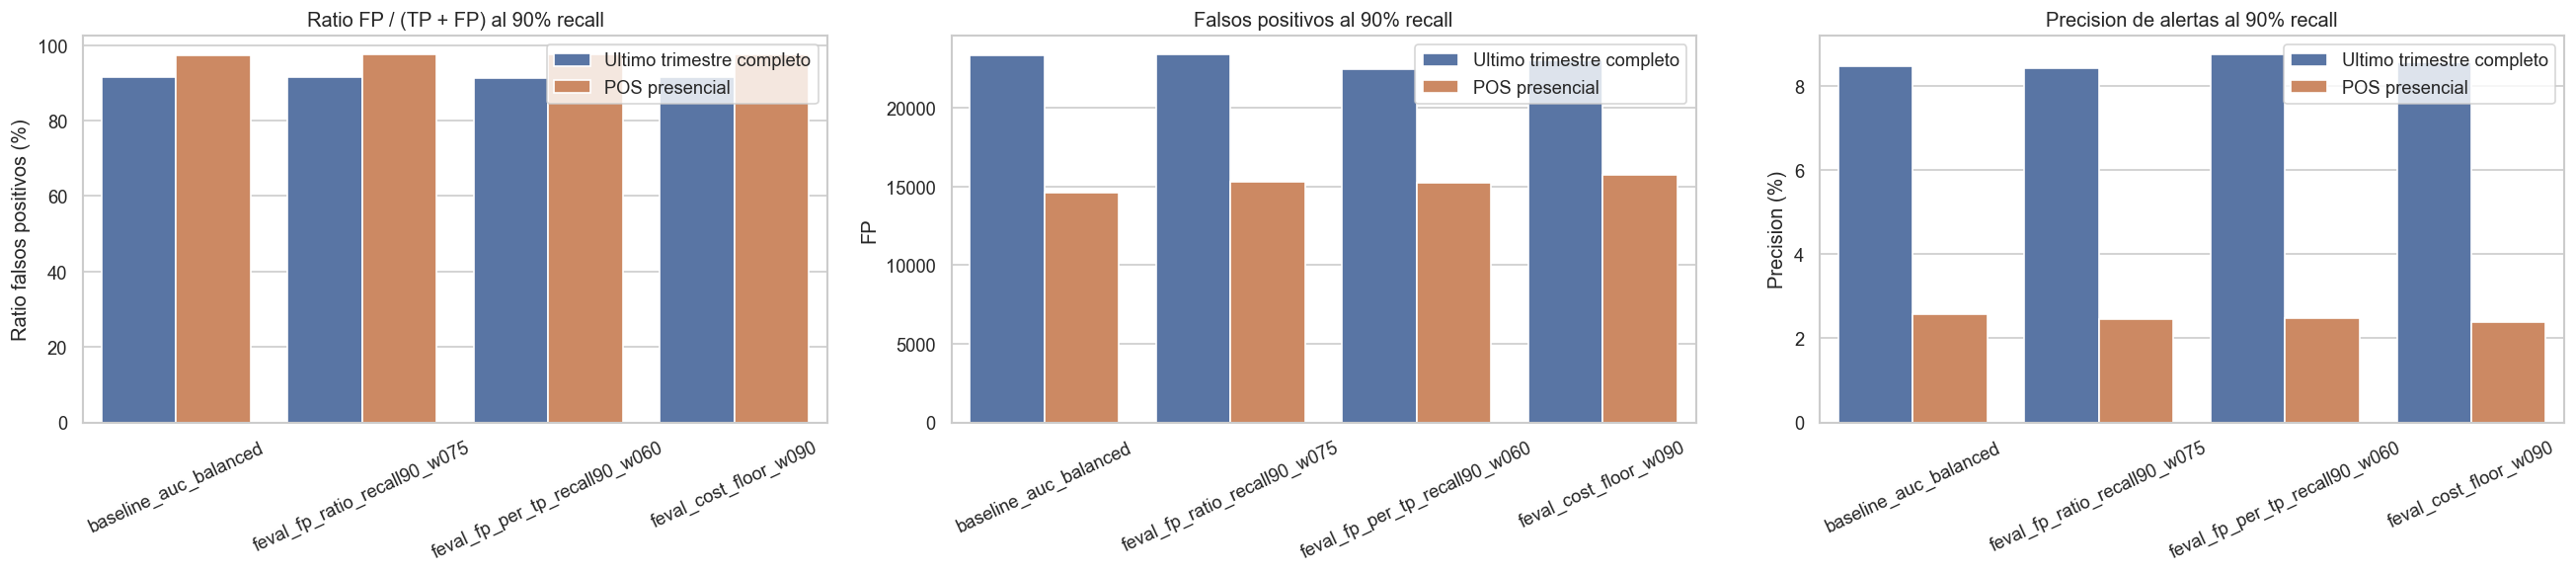

In [8]:
plot_df = comparison_df.copy()
plot_df['segment'] = plot_df['segment'].map({
    'ultimo_trimestre_todas': 'Ultimo trimestre completo',
    'ultimo_trimestre_pos': 'POS presencial',
})

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.barplot(data=plot_df, x='strategy', y='fp_ratio_recall90_pct', hue='segment', ax=axes[0])
axes[0].set_title('Ratio FP / (TP + FP) al 90% recall')
axes[0].set_ylabel('Ratio falsos positivos (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=plot_df, x='strategy', y='fp_recall90', hue='segment', ax=axes[1])
axes[1].set_title('Falsos positivos al 90% recall')
axes[1].set_ylabel('FP')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

sns.barplot(data=plot_df, x='strategy', y='precision_recall90_pct', hue='segment', ax=axes[2])
axes[2].set_title('Precision de alertas al 90% recall')
axes[2].set_ylabel('Precision (%)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=25)

for ax in axes:
    ax.legend(title='')

plt.tight_layout()
plt.show()


In [9]:
pos_rank = (
    comparison_df.query("segment == 'ultimo_trimestre_pos'")
    .sort_values(['fp_ratio_recall90_pct', 'fp_recall90', 'fp_per_tp_recall90'], ascending=[True, True, True])
    .reset_index(drop=True)
)

best = pos_rank.iloc[0]
best_custom = pos_rank[~pos_rank['strategy'].eq('baseline_auc_balanced')].iloc[0]
display(pos_rank[[
    'strategy', 'threshold_recall90', 'tp_recall90', 'fp_recall90', 'recall90_pct',
    'precision_recall90_pct', 'fp_ratio_recall90_pct', 'fp_per_tp_recall90', 'auc_roc'
]].round(4))

print('Mejor estrategia POS segun FP/(TP+FP) al 90% recall:')
print(best['strategy'])
print('\nMejor funcion feval custom segun FP/(TP+FP) al 90% recall:')
print(best_custom['strategy'])


,strategy,threshold_recall90,tp_recall90,fp_recall90,recall90_pct,precision_recall90_pct,fp_ratio_recall90_pct,fp_per_tp_recall90,auc_roc
0,baseline_auc_balanced,0.0718,385,14630,90.1639,2.5641,97.4359,38.0000,0.7756
1,feval_fp_per_tp_recall90_w060,0.0538,389,15253,91.1007,2.4869,97.5131,39.2108,0.7730
2,feval_fp_ratio_recall90_w075,0.0573,385,15332,90.1639,2.4496,97.5504,39.8234,0.7733
3,feval_cost_floor_w090,0.0739,385,15737,90.1639,2.3880,97.6120,40.8753,0.7686


Mejor estrategia POS segun FP/(TP+FP) al 90% recall:
baseline_auc_balanced

Mejor funcion feval custom segun FP/(TP+FP) al 90% recall:
feval_fp_per_tp_recall90_w060
